In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"D:\SEM_VI\PATTERN_REC\Housing.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.size

7085

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [9]:
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object

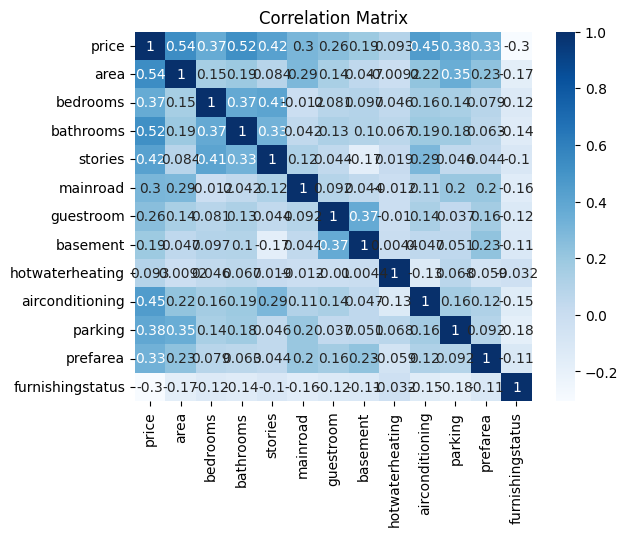

In [11]:
sns.heatmap(df.corr(),annot=True,cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [12]:
X_area = df[['area']]
y = df['price']


In [13]:
model = LinearRegression()
model.fit(X_area,y)

LinearRegression()

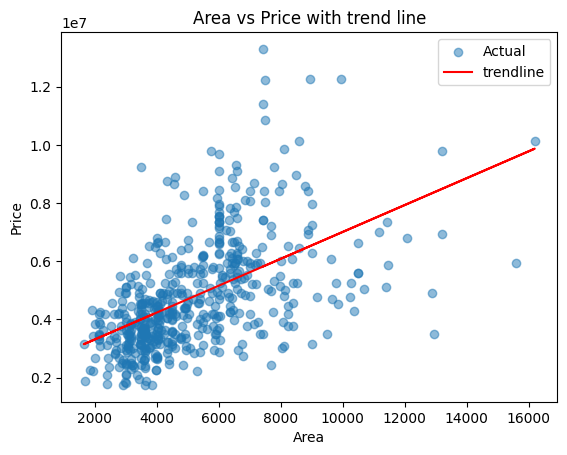

In [14]:
plt.scatter(df['area'],y,alpha=0.5,label='Actual')
plt.plot(df['area'],model.predict(X_area),color='red',label='trendline')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.title('Area vs Price with trend line')
plt.show()

In [15]:
print (f'Coefficient: {model.coef_[0]:.2f}')
print (f'Intercept: {model.intercept_:.2f}')
print (f'r2_score: {r2_score(y,model.predict(X_area)):.4f}')

Coefficient: 461.97
Intercept: 2387308.48
r2_score: 0.2873


In [16]:
feature = ['area','bedrooms','bathrooms','stories','airconditioning','parking']
X = df[feature]
y = df['price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) 
model2 = LinearRegression()
model2.fit(X_train,y_train)
y_pred = model2.predict(X_test) 

print (f'R2 Score: {r2_score(y_test,y_pred):.4f}')
print (f'Mean Squared Error: {mean_squared_error(y_test,y_pred):.2f}')

R2 Score: 0.5886
Mean Squared Error: 2079310933780.25
